In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Datos originales
X = np.array([
    [2.5, 2.4, 0.5],
    [0.5, 0.7, 1.0],
    [2.2, 2.9, 0.9],
    [1.9, 2.2, 0.6]
])

In [2]:
# Centrar los datos
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean

In [3]:
# Calcular matriz de covarianzas
cov_matrix = np.cov(X_centered, rowvar=False)

In [4]:
# Calcular valores y vectores propios
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

In [5]:
# Ordenar en orden descendente
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

In [6]:
# Proyección a 2 dimensiones
W = eigenvectors[:, :2]
X_2D = X_centered @ W

In [7]:
# Mostrar varianza retenida
total_variance = np.sum(eigenvalues)
explained_variance_2D = np.sum(eigenvalues[:2])
variance_retained_percentage = (explained_variance_2D / total_variance) * 100
print(f"Varianza retenida al reducir a 2D: {variance_retained_percentage:.2f}%")

Varianza retenida al reducir a 2D: 99.70%


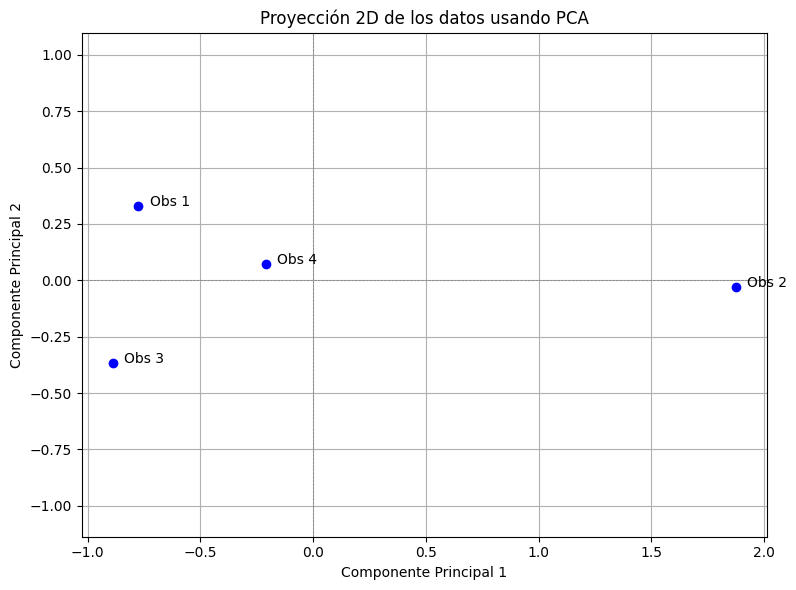

In [8]:
# Graficar resultados
labels = ['Obs 1', 'Obs 2', 'Obs 3', 'Obs 4']
plt.figure(figsize=(8, 6))
plt.scatter(X_2D[:, 0], X_2D[:, 1], color='blue')
for i, label in enumerate(labels):
    plt.text(X_2D[i, 0] + 0.05, X_2D[i, 1], label)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.title('Proyecci\u00f3n 2D de los datos usando PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()